# 🧠 Modeling Phase

### **Overview**
In this phase, we train and evaluate machine learning models to predict maintenance requirements.

---

### **Steps**

1️⃣ **Select Target & Features**  
- Define the target variable (`maintenance_required`).  
- Select relevant input features for prediction.

2️⃣ **Encode Categorical Variables**  
- Convert categorical columns (e.g., `machine_id`) to numeric using one-hot encoding.

3️⃣ **Feature Scaling**  
- Standardize numerical features to improve model performance.

4️⃣ **Train/Test Split**  
- Split data into training (80%) and testing (20%).  
- Keep class distribution balanced using stratification.

5️⃣ **Train Models**  
- Train **Random Forest Classifier**.  
- Train **XGBoost Classifier**.

6️⃣ **Hyperparameter Tuning**  
- Use **GridSearchCV** or **RandomizedSearchCV** to find the best parameters for each model.

7️⃣ **Evaluate Models**  
- Compute metrics:  
  - Accuracy  
  - F1-score (macro/weighted)  
  - ROC-AUC  
  - Confusion Matrix  
  - Classification Report

8️⃣ **Select Best Model**  
- Compare tuned models.  
- Choose the one with the highest F1-score / ROC-AUC.

9️⃣ **Save Model**  
- Save the best-performing model as a **Pickle file** for deployment.  
- Example filename: `best_model_machine_fail.pkl`

---

**Note:** Each step can be implemented in separate code cells for clarity and organization.


## 📌 Loading the Preprocessed Dataset

After completing all preprocessing steps (handling missing values, outlier removal, feature scaling, and PCA) in the data preprocessing notebook, we saved the final cleaned dataset as:

``preprocessed_smart_data.csv``

In this modeling notebook, we simply load the processed file instead of repeating the entire preprocessing pipeline:




In [1]:
import pandas as pd

hd_clean = pd.read_csv("preprocessed_smart_data.csv")
print("Loaded processed dataset:", hd_clean.shape)


Loaded processed dataset: (98538, 32)


In [2]:
hd_clean.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,...,pressure_diff,vibration_zscore,temp_zscore,vibration_ma,vibration_std,temperature_roc,vibration_roc,pressure_roc,humidity_roc,energy_consumption_roc
0,2025-01-01 01:37:00,1,62.59,48.08,60.13,1.62,4.16,1,0,363,...,NaN,-0.128943,-1.238613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 01:42:00,1,70.88,68.67,50.57,1.05,2.36,1,0,111,...,-0.57,1.245057,-0.412248,NaN,NaN,8.29,20.59,-0.57,-9.56,-1.80
2,2025-01-01 02:13:00,1,62.34,72.68,60.47,2.24,4.95,1,0,192,...,1.19,1.512650,-1.263534,NaN,NaN,-8.54,4.01,1.19,9.90,2.59
3,2025-01-01 02:19:00,1,88.03,53.36,50.79,3.08,2.25,1,0,301,...,0.84,0.223399,1.297301,NaN,NaN,25.69,-19.32,0.84,-9.68,-2.70
4,2025-01-01 03:05:00,1,79.39,49.44,56.99,2.54,2.76,1,0,127,...,-0.54,-0.038188,0.436047,NaN,NaN,-8.64,-3.92,-0.54,6.20,0.51


In [3]:
# Check for NaN values in the dataset
nan_count = hd_clean.isna().sum()
print("Columns with NaN values:\n", nan_count[nan_count > 0])

Columns with NaN values:
 temp_diff                  1
vibration_diff             1
pressure_diff              1
vibration_ma              19
vibration_std             19
temperature_roc            1
vibration_roc              1
pressure_roc               1
humidity_roc               1
energy_consumption_roc     1
dtype: int64


In [4]:
# If there are any NaNs, drop the rows
hd_clean = hd_clean.dropna()
print("Shape after dropping NaN rows:", hd_clean.shape)

Shape after dropping NaN rows: (98519, 32)


In [5]:
# Check for NaN values in the dataset
nan_count = hd_clean.isna().sum()
print("Columns with NaN values:\n", nan_count[nan_count > 0])

Columns with NaN values:
 Series([], dtype: int64)


In [6]:
hd_clean.columns

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'humidity',
       'pressure', 'energy_consumption', 'machine_status', 'anomaly_flag',
       'predicted_remaining_life', 'failure_type', 'downtime_risk',
       'maintenance_required', 'hour', 'minute', 'second', 'elapsed_time',
       'temp_roll_mean', 'vibration_roll_mean', 'pressure_roll_mean',
       'temp_diff', 'vibration_diff', 'pressure_diff', 'vibration_zscore',
       'temp_zscore', 'vibration_ma', 'vibration_std', 'temperature_roc',
       'vibration_roc', 'pressure_roc', 'humidity_roc',
       'energy_consumption_roc'],
      dtype='object')

# 🚀 Feature Selection for Machine Failure Prediction

In this section, we define the **features** that will be used by our machine learning model to predict machine failures.  
We include both **raw sensor readings** and **engineered features** that capture trends, variations, and anomalies in the machine data.

## 🟢 Raw Sensor Readings
These are the direct measurements from the machine sensors:
- `temperature` 🌡️
- `vibration` ⚡
- `humidity` 💧
- `pressure` 📊
- `energy_consumption` ⚡

 

## 🟢 Engineered Features
These are calculated features derived from the raw sensor data to provide more insights:
- **Rolling Means:** `temp_roll_mean`, `vibration_roll_mean`, `pressure_roll_mean`  
  Smooths out short-term fluctuations to capture overall trends.  
- **Differences:** `temp_diff`, `vibration_diff`, `pressure_diff`  
  Captures sudden changes in sensor readings.  
- **Z-scores and Moving Averages:** `vibration_zscore`, `temp_zscore`, `vibration_ma`, `vibration_std`  
  Standardizes sensor readings and captures statistical patterns.  
- **Rate of Change (ROC):** `temperature_roc`, `vibration_roc`, `pressure_roc`, `humidity_roc`, `energy_consumption_roc`  
  Measures the speed of change in sensor values, which can indicate anomalies.



This feature set will be used to train the model for **high performance in predicting machine failures**.  


In [7]:
features = [
    'temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption',
    'temp_roll_mean', 'vibration_roll_mean', 'pressure_roll_mean',
    'temp_diff', 'vibration_diff', 'pressure_diff',
    'vibration_zscore', 'temp_zscore', 'vibration_ma', 'vibration_std',
    'temperature_roc', 'vibration_roc', 'pressure_roc', 'humidity_roc', 'energy_consumption_roc'
]


# XGBoost Feature Importance Analysis

## Purpose
We are analyzing the importance of each feature in our dataset using XGBoost. This helps us understand:
- Which features the model relies on the most.
- Which features contribute little or nothing and can potentially be removed.




In [8]:
'''
import xgboost as xgb
import matplotlib.pyplot as plt


xgb_model.fit(X_train_smote, y_train_smote)


importance = xgb_model.feature_importances_


features_names = hd_clean[['temperature', 'vibration', 'humidity', 'pressure',
                           'energy_consumption', 
                           'temp_roll_mean', 'vibration_roll_mean', 'pressure_roll_mean',
                           'temp_diff', 'vibration_diff', 'pressure_diff',
                           'vibration_zscore', 'temp_zscore', 'vibration_ma', 'vibration_std',
                           'temperature_roc', 'vibration_roc', 'pressure_roc', 'humidity_roc', 
                           'energy_consumption_roc']].columns


feature_imp = sorted(zip(features_names, importance), key=lambda x: x[1], reverse=True)
for f, imp in feature_imp:
    print(f"{f}: {imp:.4f}")


plt.barh([f for f, _ in feature_imp], [imp for _, imp in feature_imp])
plt.xlabel("Feature Importance")
plt.show()
'''


'\nimport xgboost as xgb\nimport matplotlib.pyplot as plt\n\n\nxgb_model.fit(X_train_smote, y_train_smote)\n\n\nimportance = xgb_model.feature_importances_\n\n\nfeatures_names = hd_clean[[\'temperature\', \'vibration\', \'humidity\', \'pressure\',\n                           \'energy_consumption\', \n                           \'temp_roll_mean\', \'vibration_roll_mean\', \'pressure_roll_mean\',\n                           \'temp_diff\', \'vibration_diff\', \'pressure_diff\',\n                           \'vibration_zscore\', \'temp_zscore\', \'vibration_ma\', \'vibration_std\',\n                           \'temperature_roc\', \'vibration_roc\', \'pressure_roc\', \'humidity_roc\', \n                           \'energy_consumption_roc\']].columns\n\n\nfeature_imp = sorted(zip(features_names, importance), key=lambda x: x[1], reverse=True)\nfor f, imp in feature_imp:\n    print(f"{f}: {imp:.4f}")\n\n\nplt.barh([f for f, _ in feature_imp], [imp for _, imp in feature_imp])\nplt.xlabel("Featur

# Feature Removal Plan 

We analyzed the XGBoost feature importance and found the following features to remove:

## Zero-Importance Features
1. **pressure_diff** → Importance = 0.0000  
   - Reason: Does not contribute to the model predictions and may add noise.

2. **vibration_zscore** → Importance = 0.0000  
   - Reason: Also zero importance; removing simplifies the model.

## Low-Impact Features (Importance < 0.02)
3. **temp_roll_mean** → Importance = 0.0174  
   - Reason: Very weak influence on the model.

5. **temperature_roc** → Importance = 0.0138  
   - Reason: Minimal contribution to predictions.

6. **vibration_std** → Importance = 0.0132  
   - Reason: Very low effect on model output.

7. **pressure_roc** → Importance = 0.0126  
   - Reason: Minor influence; safe to remove.

8. **pressure_roll_mean** → Importance = 0.0120  
   - Reason: Weak contribution; can be removed.

9. **temp_diff** → Importance = 0.0112  
   - Reason: Very low effect on model predictions.

# Summary
- Removing these features will reduce noise and complexity.
- The model will focus on the features that actually influence predictions.
- The remaining features will mostly include the **raw sensor readings**, which are the most important for prediction.


In [9]:
# ===== Combined Low-Impact Features to Remove =====
features_to_remove = [
    # Previously removed zero-importance features
    'pressure_diff', 'vibration_zscore',
    
    # New low-impact features
    'temp_roll_mean', 'temperature_roc',
    'vibration_std', 'pressure_roc', 'pressure_roll_mean', 'temp_diff'
]

features = [
    'temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption',
     'vibration_roll_mean', 
     'vibration_diff', 
     'temp_zscore', 'vibration_ma', 
     'vibration_roc',  'humidity_roc', 'energy_consumption_roc'
]


## 1️⃣ Select Target & Features  
Define the target variable (`maintenance_required`) and select the important features used for prediction.  



In [10]:
X = hd_clean[features]
y = hd_clean['maintenance_required']

print("Remaining features:", features)

Remaining features: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'vibration_roll_mean', 'vibration_diff', 'temp_zscore', 'vibration_ma', 'vibration_roc', 'humidity_roc', 'energy_consumption_roc']


## 2️⃣ Encode Categorical Variables  
 Convert categorical columns such as `machine_id` to numeric form using one-hot encoding.  



In [11]:
X = pd.get_dummies(X.join(hd_clean[['machine_id']]), drop_first=True)


## 3️⃣ Feature Scaling  
 Standardize numerical data to improve model stability and performance.  



In [12]:
from sklearn.preprocessing import StandardScaler

# Use preprocessed features directly (already scaled)
X_scaled = X.values



## 4️⃣ Train/Test Split 🧪
Split the dataset into training (85%) and final testing (15%) using stratification to maintain class balance.


In [13]:
from sklearn.model_selection import train_test_split

X_train_full, X_final_test, y_train_full, y_final_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)

print("Train Full:", X_train_full.shape, "Final Test:", X_final_test.shape)


Train Full: (83741, 13) Final Test: (14778, 13)


## 🔧 Applying SMOTE to Balance the Training Data

We apply **SMOTE** to oversample the minority class in the training set.  
This helps fix class imbalance and improves the model’s recall and F1-score.  
SMOTE is applied **only to the training data** to avoid data leakage.


In [14]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(X_train_full, y_train_full)

print("Before SMOTE:\n", y_train_full.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())


Before SMOTE:
 maintenance_required
0    67695
1    16046
Name: count, dtype: int64

After SMOTE:
 maintenance_required
0    67695
1    67695
Name: count, dtype: int64


## 5️⃣ Setup Cross-Validation 🔄
Use Stratified K-Fold cross-validation to evaluate the model reliably.


In [15]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 🌲Training Random Forest on the SMOTE-Balanced Dataset

We train the Random Forest classifier using the balanced data  
generated by SMOTE.  
Class weights are not needed because SMOTE already balances the dataset.


In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

cv_acc = cross_val_score(rf, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(rf, X_train_smote, y_train_smote, cv=cv, scoring='f1')

print("\n===== Cross-Validation Results =====")
print("Fold Accuracies:", cv_acc)
print("Mean CV Accuracy:", cv_acc.mean())
print("-------------------------------------")
print("Fold F1 Scores:", cv_f1)
print("Mean CV F1:", cv_f1.mean())






===== Cross-Validation Results =====
Fold Accuracies: [0.86335771 0.86265603 0.86343157 0.86849103 0.86734619]
Mean CV Accuracy: 0.8650565034345226
-------------------------------------
Fold F1 Scores: [0.84965461 0.84864271 0.8496748  0.85528508 0.85452778]
Mean CV F1: 0.8515569962674656


## 2️⃣ Train Random Forest on Full Training Data ✅
Train the Random Forest model on the full training dataset.


In [88]:
rf.fit(X_train_smote, y_train_smote)


RandomForestClassifier(n_estimators=300, random_state=42)

## 3️⃣ Final Testing on Unseen Data 🧩
Evaluate the Random Forest model on the final hold-out test set.


In [89]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_final = rf.predict(X_final_test)

final_acc = accuracy_score(y_final_test, y_pred_final)
final_f1 = f1_score(y_final_test, y_pred_final)

print("\n===== Final Unseen Test Performance =====")
print("Final Accuracy:", final_acc)
print("Final F1 Score:", final_f1)



===== Final Unseen Test Performance =====
Final Accuracy: 0.8667614020841792
Final F1 Score: 0.5698055494865633


## 4️⃣ Compare Random Forest CV vs Final Test 📊
Compare cross-validation results with final test performance.


In [90]:
print("\n===== Comparison: CV vs Final Test =====")
print("CV Mean Accuracy:", cv_acc.mean())
print("Final Test Accuracy:", final_acc)
print("-------------------------------------")
print("CV Mean F1:", cv_f1.mean())
print("Final Test F1:", final_f1)



===== Comparison: CV vs Final Test =====
CV Mean Accuracy: 0.8650565034345226
Final Test Accuracy: 0.8667614020841792
-------------------------------------
CV Mean F1: 0.8515569962674656
Final Test F1: 0.5698055494865633


## 1️⃣ XGBoost Cross-Validation 🚀
Train an XGBoost classifier and evaluate using cross-validation for accuracy and F1 score.


In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score


xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)


cv_acc_xgb = cross_val_score(xgb_model, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')
cv_f1_xgb  = cross_val_score(xgb_model, X_train_smote, y_train_smote, cv=cv, scoring='f1')


print("\n===== XGBoost Cross-Validation Results =====")
print("Fold Accuracies:", cv_acc_xgb)
print("Mean CV Accuracy:", cv_acc_xgb.mean())
print("-------------------------------------")
print("Fold F1 Scores:", cv_f1_xgb)
print("Mean CV F1:", cv_f1_xgb.mean())




c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:52:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:52:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:52:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:52:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,


===== XGBoost Cross-Validation Results =====
Fold Accuracies: [0.85833518 0.85213088 0.86029249 0.86365315 0.86099417]
Mean CV Accuracy: 0.8590811729078958
-------------------------------------
Fold F1 Scores: [0.83689089 0.82824296 0.83930164 0.84329372 0.84040027]
Mean CV F1: 0.8376258981112784


## 2️⃣ Train XGBoost on Full Training Data ✅
Train the XGBoost model on the full training dataset.


In [17]:
xgb_model.fit(X_train_smote, y_train_smote)


c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:52:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

## 3️⃣ Final Testing on Unseen Data 🧩
Evaluate the XGBoost model on the final hold-out test set.


In [18]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


y_pred_final_xgb = xgb_model.predict(X_final_test)

final_acc_xgb = accuracy_score(y_final_test, y_pred_final_xgb)
final_f1_xgb = f1_score(y_final_test, y_pred_final_xgb)

print("===== XGBoost Final Test Results =====")
print("Final Accuracy:", final_acc_xgb)
print("Final F1 Score:", final_f1_xgb)
print("\nConfusion Matrix:")
print(confusion_matrix(y_final_test, y_pred_final_xgb))
print("\nClassification Report:")
print(classification_report(y_final_test, y_pred_final_xgb))


===== XGBoost Final Test Results =====
Final Accuracy: 0.8870618486940046
Final F1 Score: 0.6013852400286601

Confusion Matrix:
[[11850    96]
 [ 1573  1259]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     11946
           1       0.93      0.44      0.60      2832

    accuracy                           0.89     14778
   macro avg       0.91      0.72      0.77     14778
weighted avg       0.89      0.89      0.87     14778



## 4️⃣ Compare XGBoost CV vs Final Test 📊
Compare cross-validation results with final test performance.


In [19]:
print("===== XGBoost CV vs Final Test Comparison =====")
print(f"CV Mean Accuracy: {cv_acc_xgb.mean():.4f}")
print(f"Final Test Accuracy: {final_acc_xgb:.4f}")
print("-------------------------------------")
print(f"CV Mean F1: {cv_f1_xgb.mean():.4f}")
print(f"Final Test F1: {final_f1_xgb:.4f}")


===== XGBoost CV vs Final Test Comparison =====
CV Mean Accuracy: 0.8591
Final Test Accuracy: 0.8871
-------------------------------------
CV Mean F1: 0.8376
Final Test F1: 0.6014


## 1️⃣ Define Hyperparameter Grid 🧩
Specify the range of hyperparameters to search for the Random Forest model.


In [84]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

rf_model = RandomForestClassifier(random_state=42)


## 2️⃣ Setup Randomized Search 🔄
Use RandomizedSearchCV to find the best hyperparameters based on F1-score.


In [85]:
from sklearn.model_selection import RandomizedSearchCV

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_params,
    n_iter=20,
    cv=cv,   # StratifiedKFold 5-fold cross-validation
    scoring='f1',
    n_jobs=-1,
    random_state=42
)


## 3️⃣ Fit Randomized Search 🔥
Train the RandomizedSearchCV on the full training dataset to find the best hyperparameters.


In [ ]:
rf_random_search.fit(X_train_full, y_train_full)
best_rf = rf_random_search.best_estimator_

print("Best Random Forest Parameters:", rf_random_search.best_params_)


## 4️⃣ Final Testing on Unseen Data 🧩 (Best Random Forest)
Evaluate the best Random Forest model on the final hold-out test set.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred_best_rf = best_rf.predict(X_final_test)

final_acc_best_rf = accuracy_score(y_final_test, y_pred_best_rf)
final_f1_best_rf = f1_score(y_final_test, y_pred_best_rf)
conf_matrix_best_rf = confusion_matrix(y_final_test, y_pred_best_rf)
class_report_best_rf = classification_report(y_final_test, y_pred_best_rf)

print("Final Accuracy (Best RF):", final_acc_best_rf)
print("Final F1 Score (Best RF):", final_f1_best_rf)
print("\nConfusion Matrix:\n", conf_matrix_best_rf)
print("\nClassification Report:\n", class_report_best_rf)


## 5️⃣ Compare CV vs Final Test 📊 (Best Random Forest)
Compare cross-validation results with final test performance of the best Random Forest model.


In [ ]:
print("Best RF CV Mean F1:", rf_random_search.best_score_)
print("Final Test F1:", final_f1_best_rf)
print("-------------------------------------")
print("Final Test Accuracy:", final_acc_best_rf)


## 1️⃣ Define Hyperparameter Grid 🧩 (XGBoost)
Specify the range of hyperparameters to search for the XGBoost model.


In [96]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


## 2️⃣ Setup Randomized Search 🔄 (XGBoost)
Use RandomizedSearchCV to find the best hyperparameters based on F1-score.


In [97]:
from sklearn.model_selection import RandomizedSearchCV

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=20,
    cv=cv,   # StratifiedKFold 5-fold cross-validation
    scoring='f1',
    n_jobs=-1,
    random_state=42
)


## 3️⃣ Fit Randomized Search 🔥 (XGBoost)
Train the RandomizedSearchCV on the full training dataset to find the best hyperparameters.


In [ ]:

xgb_random_search.fit(X_train_smote, y_train_smote)

best_xgb = xgb_random_search.best_estimator_

print("Best XGBoost Parameters:", xgb_random_search.best_params_)


## 4️⃣ Final Testing on Unseen Data 🧩 (Best XGBoost)
Evaluate the best XGBoost model on the final hold-out test set.


In [ ]:
y_pred_best_xgb = best_xgb.predict(X_final_test)

final_acc_best_xgb = accuracy_score(y_final_test, y_pred_best_xgb)
final_f1_best_xgb = f1_score(y_final_test, y_pred_best_xgb)
conf_matrix_best_xgb = confusion_matrix(y_final_test, y_pred_best_xgb)
class_report_best_xgb = classification_report(y_final_test, y_pred_best_xgb)

print("Final Accuracy (Best XGB):", final_acc_best_xgb)
print("Final F1 Score (Best XGB):", final_f1_best_xgb)
print("\nConfusion Matrix:\n", conf_matrix_best_xgb)
print("\nClassification Report:\n", class_report_best_xgb)


Final Accuracy (Best XGB): 0.8560313916514444
Final F1 Score (Best XGB): 0.551622418879056

Confusion Matrix:
 [[11344   605]
 [ 1523  1309]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     11949
           1       0.68      0.46      0.55      2832

    accuracy                           0.86     14781
   macro avg       0.78      0.71      0.73     14781
weighted avg       0.84      0.86      0.84     14781



## 5️⃣ Compare CV vs Final Test 📊 (Best XGBoost)
Compare cross-validation results with final test performance of the best XGBoost model.


In [ ]:
print("Best XGB CV Mean F1:", xgb_random_search.best_score_)
print("Final Test F1:", final_f1_best_xgb)
print("-------------------------------------")
print("Final Test Accuracy:", final_acc_best_xgb)


Best XGB CV Mean F1: 0.8571738848385067
Final Test F1: 0.551622418879056
-------------------------------------
Final Test Accuracy: 0.8560313916514444


## 3️⃣ Compare Best-Tuned Models 🔥
Evaluate both tuned models (Random Forest & XGBoost) and decide which performs better based on Accuracy, F1-score, and ROC-AUC.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(model, name):
    y_pred = model.predict(X_final_test)
    y_prob = model.predict_proba(X_final_test)[:, 1]
    print(f"\n===== {name} Results =====")
    print("Accuracy:", accuracy_score(y_final_test, y_pred))
    print("F1-score:", f1_score(y_final_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_final_test, y_prob))
    return f1_score(y_final_test, y_pred)

rf_f1  = evaluate(best_rf, "Random Forest")
xgb_f1 = evaluate(best_xgb, "XGBoost")

best_model = best_xgb if xgb_f1 > rf_f1 else best_rf
print("\n🔥 Best Model Selected:", "XGBoost" if best_model == best_xgb else "Random Forest")


# 📈 ROC Curve & AUC – Detailed Explanation

## 🔹 Introduction
Accuracy and F1-score alone are not enough to evaluate a model, especially with imbalanced datasets.  
That’s why we use **ROC Curve** and **AUC Score**, which show how well the model distinguishes between classes at different thresholds.

---

# 1️⃣ Getting Predicted Probabilities




🔥 Final Test AUC Score: 0.7230971723272618


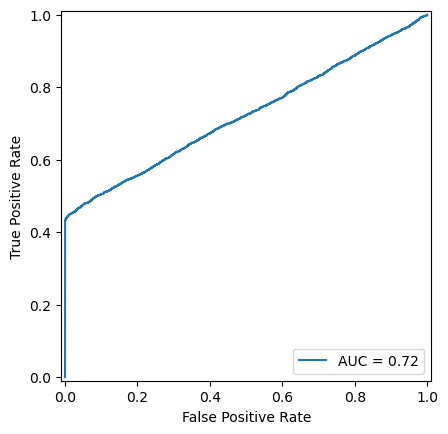

In [21]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 1) Get probabilities for class 1
y_prob_final = xgb_model.predict_proba(X_final_test)[:, 1]

# 2) Compute FPR & TPR
fpr, tpr, thresholds = roc_curve(y_final_test, y_prob_final)

# 3) Compute AUC
roc_auc = auc(fpr, tpr)

print("🔥 Final Test AUC Score:", roc_auc)

# 4) Plot ROC Curve
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()


## 4️⃣ Save Best Model using Pickle  
 Save the best-performing model to a `.pkl` file for deployment.  



In [99]:
import pickle

best_model_name = "best_model_machine_fail.pkl"

with open(best_model_name, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"🔥 XGBoost model saved as {best_model_name}")


🔥 XGBoost model saved as best_model_machine_fail.pkl


# 💾 Saving Final Feature List

This snippet saves the **final features** that were actually used in the model after removing low-impact ones.




In [102]:
import pickle

# Save final feature list used in the model
final_features = features  
with open("columns.pkl", "wb") as f:
    pickle.dump(final_features, f)

print("✔ Saved  columns.pkl successfully!")


✔ Saved  columns.pkl successfully!
